# 1. Αρχικοποίηση και Configuration

## Πού βρισκόμαστε στον AIoT lifecycle
Αυτό το notebook υλοποιεί τα **Βήματα 3 (Explore the Data)** και **4 (Prepare the Data)** του 8-step ML project checklist. Παίρνει τα 27 session documents από τη MongoDB που παράγει το upstream dataset-creation notebook, εκτελεί signal-level EDA, segmentation σε παράθυρα σταθερού μήκους, outlier removal και subject-based split, και παράγει το cache `segmented.pkl` που τροφοδοτεί τα downstream modeling notebooks (engineered features + raw time-series).

## Tooling
Φόρτωση των βιβλιοθηκών, ενεργοποίηση auto-reload για το `utils.py` (διευκολύνει το iterative development), και parsing του `config.yml`. Όλες οι τιμές των hyperparameters (sliding window, filter, outlier thresholds, train / test users) ζουν εκεί - κανένα magic number στο notebook.


In [1]:
import os
import yaml
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from pymongo import MongoClient
from scipy.stats import zscore

from utils import sliding_window_pd, save_results
from utils_visual import plot_average_durations, plot_signal_histograms, plot_windows_per_class 

# Load Config (explicit utf-8 encoding for cross-platform consistency)
with open(os.path.join(os.getcwd(), "config.yml"), encoding="utf-8") as _f:
    cfg = yaml.safe_load(_f)

# 2. Data Ingestion & Parquet Caching

## Γιατί MongoDB → DataFrame
Τα **27 documents** φορτώνονται από τη MongoDB collection. Κάθε document γίνεται unflattened σε ένα DataFrame row-per-sample (κάθε γραμμή = ένα sample 100-Hz), διατηρώντας το metadata (`gesture_id`, `user`, `session_id`, ...) ως αντιγραμμένες στήλες. Αυτό μετατρέπει το ιεραρχικό document storage σε flat tabular form, ευκολότερη για downstream processing. Συνολικά παράγονται **454.413 samples** σε όλες τις 27 sessions.

## Γιατί Parquet cache
Καταγράφουμε το flattened DataFrame στο `outputs/cache/gestures_clean.parquet`:
- **Columnar storage** → γρήγορα reads μόνο των χρειαζόμενων στηλών.
- **Compressed** → 23 MB αντί για ~80 MB σε CSV.
- **Type-preserving** → δεν χάνουμε numeric precision, όπως θα συνέβαινε με CSV serialization.
- **Idempotent**: τα επόμενα re-runs μπορούν να διαβάσουν απευθείας από parquet αντί να επιστρέψουν στη MongoDB (που είναι πιο αργή και απαιτεί running service).

Αυτό αντιστοιχεί στην αρχή του "Get the Data": *"Convert the data to a format you can easily manipulate (without changing the data itself)"*.


In [2]:
coll = MongoClient(cfg["client"])[cfg["db"]][cfg["col"]]
docs = list(coll.find({}, {"_id": 0})) # Fetch 27 documents

records = []
for d in docs:
    sub = pd.DataFrame(d["data"])
    for k in ("gesture_id", "finger", "typing_style", "hand", "sr", "sensor", "primary", "spontaneous", "user", "session_id"):
        sub[k] = d[k]
    records.append(sub)

df_all = pd.concat(records, ignore_index=True)

cache_path = Path(cfg["out_cache"]) / "gestures_clean.parquet"
cache_path.parent.mkdir(parents=True, exist_ok=True)
df_all.to_parquet(cache_path)

print(f"Cached {len(df_all)} samples across {len(docs)} sessions.")

Cached 454413 samples across 27 sessions.


# 3. Signal-Level EDA + Scaling Justification

## Γιατί EDA πριν από το segmentation
Πριν χωρίσουμε το signal σε παράθυρα, πρέπει να καταλάβουμε **τι μετράμε**: τι range έχουν τα channels, πόσο heavy-tailed είναι, πόσο διαφέρουν τα subjects.

## Signal-level statistics ανά channel
Το `df.describe()` δίνει per-channel summary (mean, std, min / max, percentiles). Επιπλέον υπολογίζουμε skewness και **kurtosis** - τα δύο shape statistics που χρειαζόμαστε για να δικαιολογήσουμε την επιλογή scaler.

## Mixed scaling: γιατί StandardScaler για acc και RobustScaler για gyr
Το **per-channel scaling** είναι το recommended default, γιατί τα channels μετρούν φυσικά διαφορετικά μεγέθη (`g` για acc vs `rad/s` για gyr).
- Το **sensor-type grouped** scaling είναι πρακτικό middle ground: όλα τα acc channels με έναν scaler, όλα τα gyr με έναν άλλον.

Η επιλογή scaler ανά sensor type δικαιολογείται εμπειρικά εδώ:

| Scaler | Center | Scale | Outlier robust |
|---|---|---|---|
| **StandardScaler** | mean | std dev | Low |
| **RobustScaler** | median | IQR | High |

Υπολογίζοντας την kurtosis, αποδεικνύουμε ότι τα **gyroscope channels εμφανίζουν heavy-tailed distributions** (impact spikes κατά τη διάρκεια των χειρονομιών). Σε ένα heavy-tailed signal, ο mean και ο std παραμορφώνονται από τα outliers, οπότε ο `RobustScaler` (median + IQR) είναι η σωστή επιλογή για gyr. Για acc, που είναι σχεδόν Gaussian-distributed γύρω από την gravity component, ο `StandardScaler` είναι κατάλληλος.

Η απόφαση υλοποιείται downstream στον `ColumnTransformer` του engineered-feature pipeline. Το cell εδώ παράγει το παρατηρησιακό evidence.

## Class duration analysis
Παράγουμε το `eda_class_durations.png` που δείχνει τη μέση διάρκεια κάθε gesture class. Συσχετίζεται με το πόσα windows θα παραχθούν ανά class στο επόμενο cell (longer sessions → περισσότερα windows).


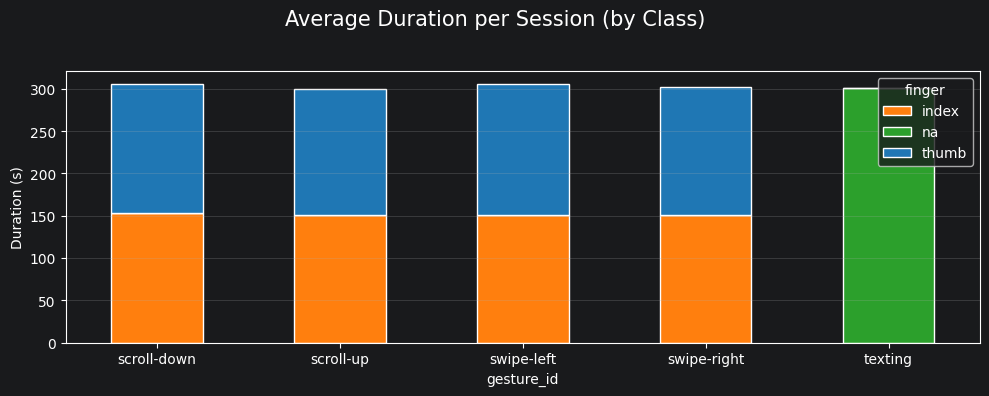

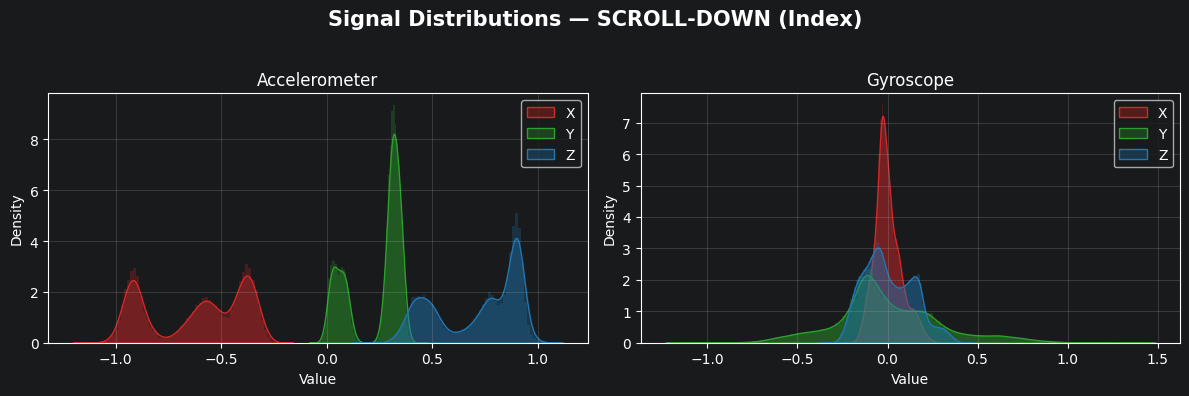

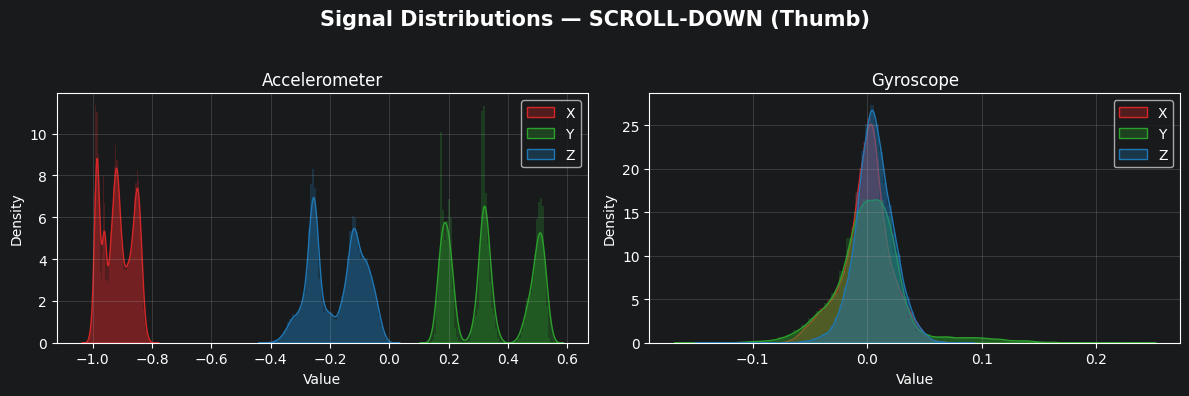

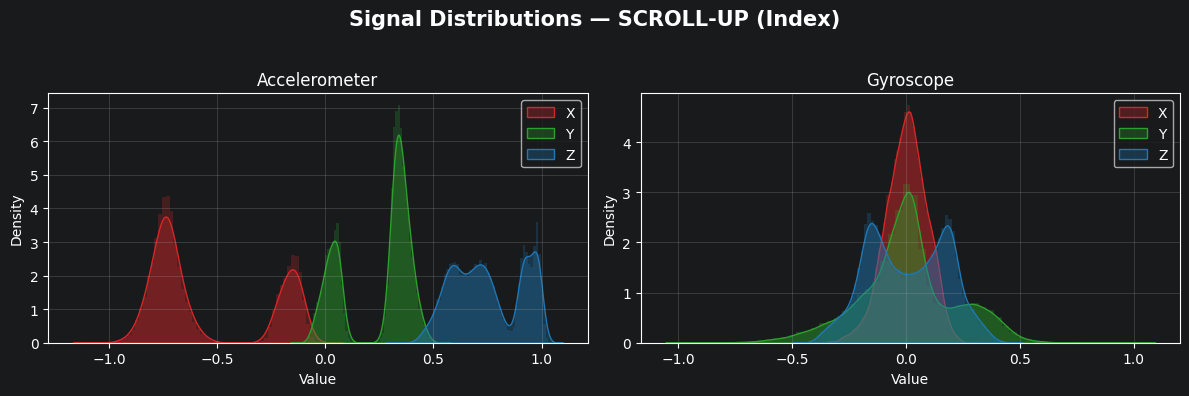

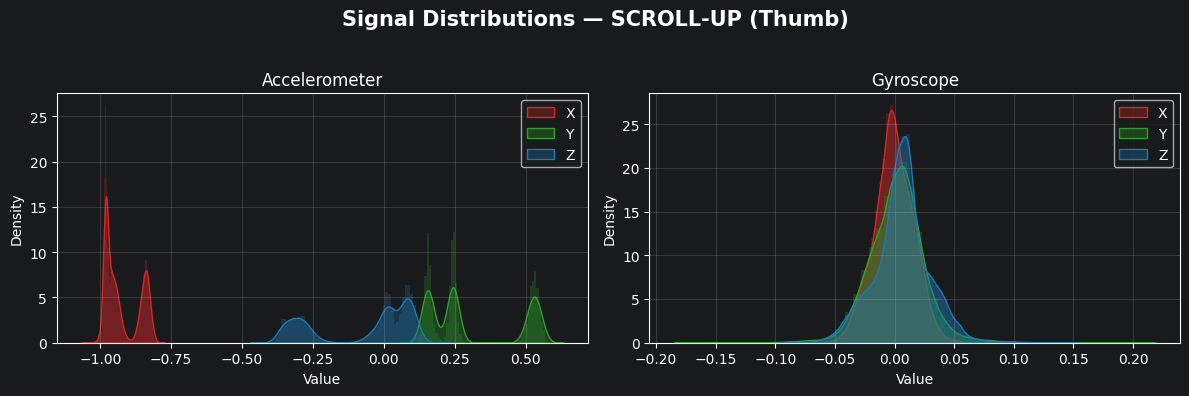

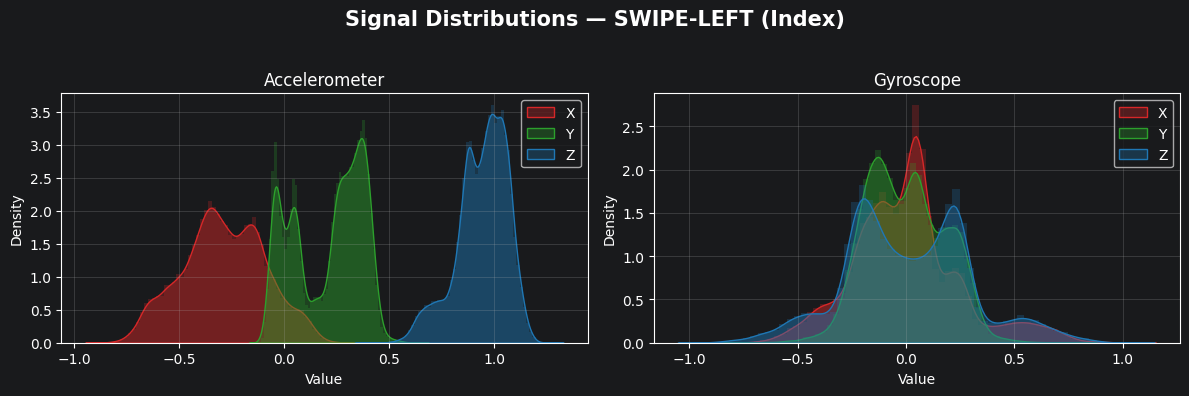

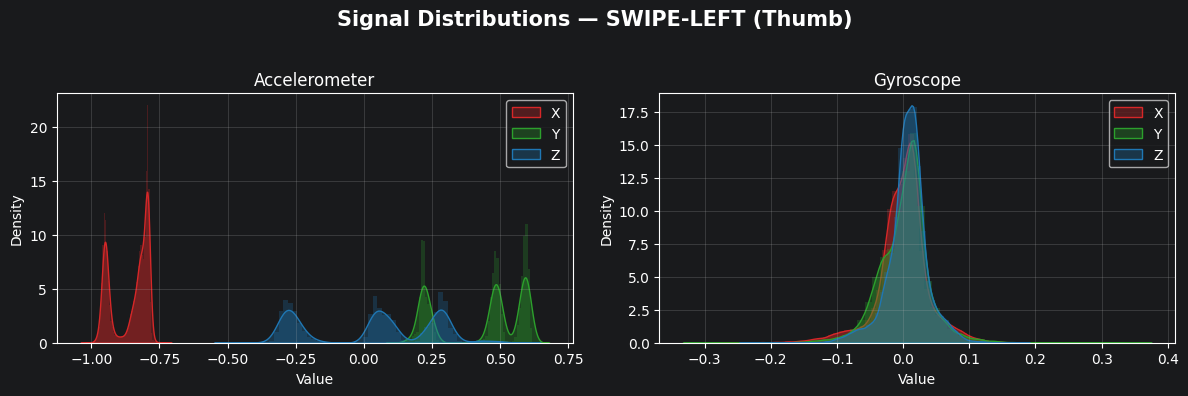

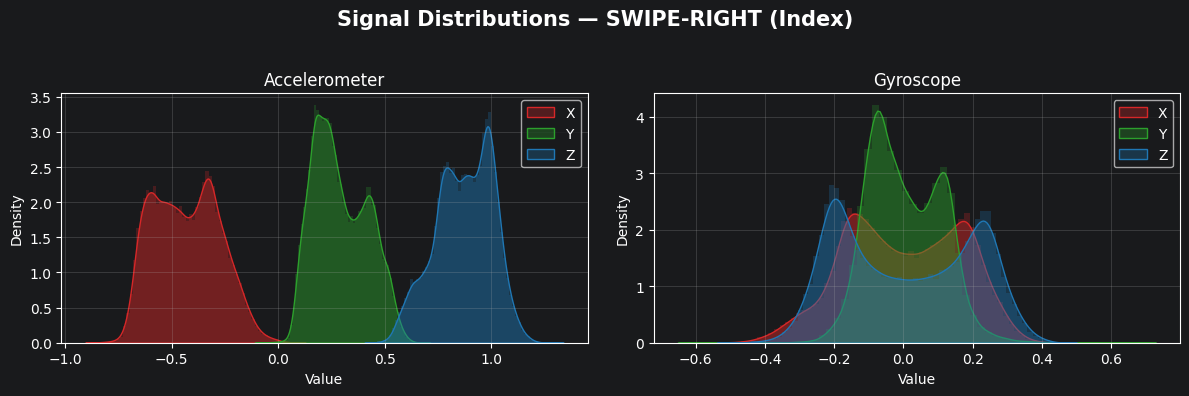

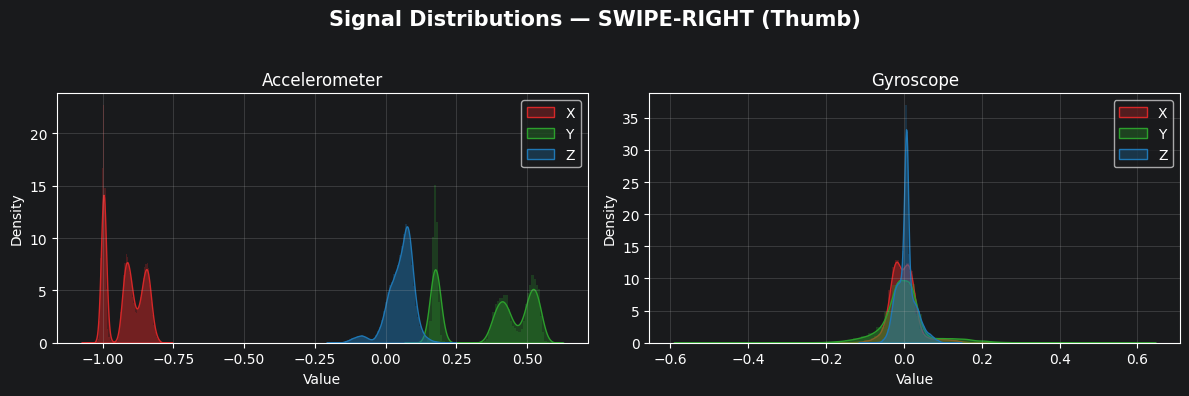

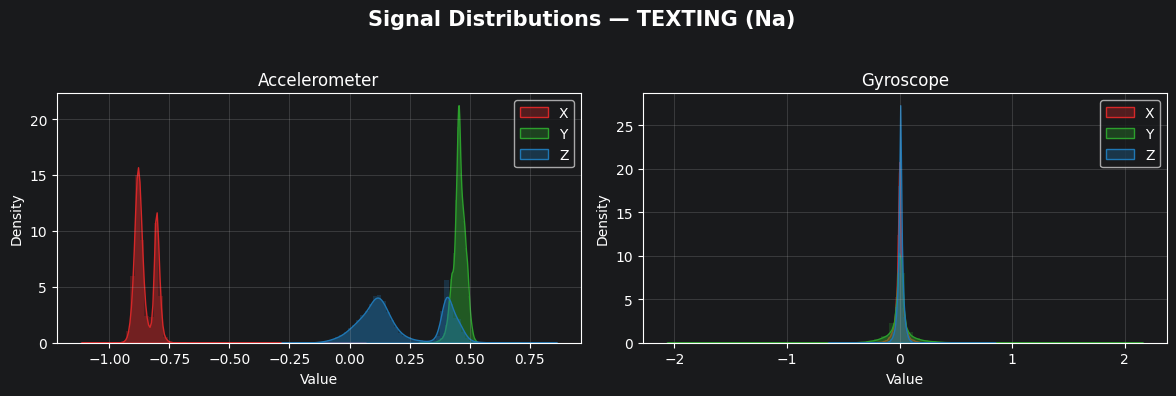

In [3]:
# Per-axis stats (mixed scaling)
desc = df_all[["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]].describe(percentiles=[.25, .5, .75]).T
desc["skew"] = df_all[["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]].skew()
desc["kurt"] = df_all[["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]].kurt()
save_results(desc.reset_index(), "eda_per_axis_stats")

# Class duration stats and signal distribution histograms
plot_average_durations(df_all)
plot_signal_histograms(df_all)

# 4. Time-Series Segmentation (Sliding Window)

## Από συνεχές stream σε labelled segments
Η naive προσέγγιση να εξαχθεί κάθε annotated block ως ένα sample αποτυγχάνει, γιατί:
- Τα blocks έχουν **wildly different durations** (μερικά seconds vs δεκάδες seconds).
- Τα statistical και neural network models περιμένουν **fixed-length inputs**.
- Δημιουργείται class imbalance αν κάποιες activities καταγράφονται για περισσότερο.

**Λύση**: Time-Series Segmentation μέσω Sliding Window.

## Παράμετροι (από `config.yml`)
| Param | Value | Effect |
|---|---|---|
| Window length `L` | `ws = 200 samples = 2s @ 100 Hz` | Context vs activity mixing |
| Step size `S` | `overlap = 100 samples = 1s` | 50% overlap, 1 παράθυρο/sec |
| Windowing function | `hann` (config), αλλά εφαρμόζεται μόνο όταν καλείται aggregation πάνω στο rolling object - όχι στα raw slices που εξάγουμε εδώ | - |
| Centering | `w_center = True` | Window label = κέντρο, όχι δεξιά άκρη |

Το `L = 1-3 s` είναι το τυπικό εύρος για HAR (*"1-3s (50-300 samples)"*). Το overlap 50% είναι από τα πιο συχνά επιλεγμένα (50% ή 75%).

Το συνολικό αποτέλεσμα είναι **4 506 παράθυρα** σε όλες τις sessions.

## Σειρά του pipeline και leakage prevention
Η σωστή σειρά είναι:
1. Raw sensor data
2. Cleaning + imputation
3. Filtering
4. **Train / Val / Test split** (by subject, ποτέ random window index)
5. Sliding window segmentation (κάθε split ανεξάρτητα)
6. Fit scaler on train only
7. Transform all splits
8. Feature extraction / model

Εμείς κάνουμε windowing **πριν** το split (cell 7) και split **μετά** (cell 11). Αυτό είναι ασφαλές γιατί κάνουμε split **by user** (όχι by window index), οπότε τα overlapping παράθυρα του ίδιου user πέφτουν όλα στο ίδιο split. Έτσι αποφεύγεται το **window leakage**, αφού δεν χρησιμοποιούμε random shuffle.

## Label assignment
Κάθε session έχει ένα μοναδικό `gesture_id` και έναν μοναδικό `user`, οπότε όλα τα παράθυρα του session παίρνουν αυτό το label χωρίς ambiguity (δεν υπάρχει ανάγκη majority-vote, όπως σε multi-activity recordings).


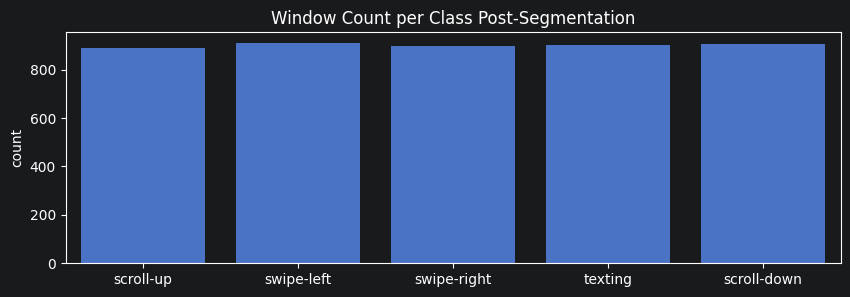

In [4]:
all_windows, all_labels, all_users, all_session_ids = [], [], [], []

# Segmentation using sliding window (per session)
for sid, sub in df_all.groupby("session_id"):
    df_sess = sub[["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]].reset_index(drop=True)
    label = sub["gesture_id"].iloc[0]
    user = sub["user"].iloc[0]
    
    windows = sliding_window_pd(
        df_sess,
        ws=cfg["sliding_window"]["ws"],
        overlap=cfg["sliding_window"]["overlap"],
        w_type=cfg["sliding_window"]["w_type"],
        w_center=cfg["sliding_window"].get("w_center", True),
        print_stats=False
    )
    
    all_windows.extend(windows)
    all_labels.extend([label] * len(windows))
    all_users.extend([user] * len(windows))
    all_session_ids.extend([sid] * len(windows))

# Post-segmentation class balance check
plot_windows_per_class(all_labels) 

# 5. Outlier Detection + Removal Ledger

## Γιατί windows-level outlier check
Παρά το upstream lowpass filtering, μπορεί να έχουν επιβιώσει παράθυρα με data quality issues:
- **NaN values**: από drops του Bluetooth κατά τη συλλογή που δεν καλύφθηκαν από interpolation upstream.
- **Severe z-score outliers (|z| > 4)**: spurious spikes από electrostatic discharge ή mechanical shock.
- **Accelerometer saturation στο `±8g`**: όταν η χειρονομία ξεπερνά το dynamic range του αισθητήρα, η τιμή "κολλάει" στο max - δεν είναι αληθινό measurement.

Αυτά είναι τα κανονικά failure modes ενός IMU.

## Removal policy
Για κάθε παράθυρο ελέγχουμε σειριακά:
1. Αν περιέχει NaN → drop, λόγος `"NaN"`.
2. Αν > 5% των rows έχει `|z-score| > 4` → drop, λόγος `"z>4 outliers >5%"`.
3. Αν οποιοδήποτε acc value είναι `≥ 7.9 g` (κοντά στο όριο saturation `±8g`) → drop, λόγος `"acc saturation"`.

Όλα τα discarded windows γράφονται στο `outputs/results/preprocessing_removed_windows.csv` (το **removal ledger**), ώστε να υπάρχει transparent trail για το report.

Στο τρέχον dataset, και τα **4 506 / 4 506 παράθυρα** περνούν και τους τρεις ελέγχους - το upstream filtering ήταν αποτελεσματικό και δεν χρειάστηκε καμία αφαίρεση.

## Reporting transparency
Το ledger είναι σημαντικό για το final report γιατί:
- Αναφέρει πόσα παράθυρα χάθηκαν ανά subject/class - επιτρέπει honest assessment του class balance μετά από cleaning.
- Διατηρεί reproducibility: ο reader μπορεί να επανεξετάσει αν κάποιες classes χάνουν δυσανάλογα παράθυρα.


In [5]:
removal_rows, keep_mask = [], []

for idx, win in enumerate(all_windows):
    arr = win[["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]].values
    
    if np.isnan(arr).any():
        removal_rows.append({"idx": idx, "user": all_users[idx], "label": all_labels[idx], "reason": "NaN"})
        keep_mask.append(False)
        continue
        
    if (np.abs(zscore(arr, axis=0)) > 4).mean() > 0.05:
        removal_rows.append({"idx": idx, "user": all_users[idx], "label": all_labels[idx], "reason": "z>4 outliers >5%"})
        keep_mask.append(False)
        continue
        
    if (np.abs(arr[:, :3]) >= 7.9).any(): # acc saturation @ ±8g
        removal_rows.append({"idx": idx, "user": all_users[idx], "label": all_labels[idx], "reason": "acc saturation"})
        keep_mask.append(False)
        continue
        
    keep_mask.append(True)

removal_df = pd.DataFrame(removal_rows)
save_results(removal_df, "preprocessing_removed_windows")
print(f"Kept {sum(keep_mask)}/{len(keep_mask)} windows.")

# Apply masks
all_windows = [w for w, k in zip(all_windows, keep_mask) if k]
all_labels = [l for l, k in zip(all_labels, keep_mask) if k]
all_users = [u for u, k in zip(all_users, keep_mask) if k]

Kept 4506/4506 windows.


# 6. Subject-Based Train / Test Split

## Γιατί by-subject και όχι random
Το **window leakage** είναι από τα πιο επικίνδυνα failure modes σε HAR:

> *Splitting after windowing + random shuffle ⇒ overlapping windows shared across train and test.*

Αν δύο παράθυρα με 50%-overlap του ίδιου user πέσουν τυχαία ένα στο train και ένα στο test, ο classifier ουσιαστικά memorises subject identity αντί gesture pattern, και το test score γίνεται artificially high. Η λύση: **split at the recording / subject level *before* windowing**, ή ισοδύναμα, split by subject με όλα τα παράθυρα του ίδιου subject να μένουν μαζί.

## Η default σύμβαση εδώ
- `train_users = ["a", "b"]` → train mask (3 012 παράθυρα)
- `test_users = ["s"]` → test mask (1 494 παράθυρα)

Παράγουμε `train_mask` και `test_mask` ως boolean arrays πάνω στο `users_arr`. Το assertion `set(users_arr[train_mask]).isdisjoint(set(users_arr[test_mask]))` εγγυάται μηδενική επικάλυψη subjects.

## Σημαντική σημείωση για το downstream feature-engineering pipeline
Οι μάσκες train / test που γράφονται στο `segmented.pkl` αντιστοιχούν στην αρχική σύμβαση single-split (`a + b → s`). Το feature-engineering notebook **τις αγνοεί** και υλοποιεί leave-one-subject-out αξιολόγηση τρέχοντας τρία folds (`(a,b) → s`, `(a,s) → b`, `(b,s) → a`), βασιζόμενο μόνο στη στήλη `users`. Οι μάσκες διατηρούνται εδώ για backward compatibility με οποιοδήποτε pipeline τρέχει στο single-split scheme.

Η ευρύτερη αρχή για test set isolation παραμένει: *"Sample a test set, put it aside, and never look at it (no data snooping!)"*. Το test set (όποιος και αν είναι ο held-out subject) δεν επηρεάζει EDA, ANOVA, correlation pruning, scaler fit, ή hyperparameter selection.


In [6]:
users_arr = np.array(all_users)
labels_arr = np.array(all_labels)

train_mask = np.isin(users_arr, cfg["train_users"]) # ["a", "b"]
test_mask = np.isin(users_arr, cfg["test_users"])   # ["s"]

# Validation: NO subject leakage
assert set(users_arr[train_mask]).isdisjoint(set(users_arr[test_mask]))
print(f"Train windows: {train_mask.sum()}, Test windows: {test_mask.sum()}")

Train windows: 3012, Test windows: 1494


# 7. Segmented Cache Generation

## Single source of truth
Το `outputs/cache/segmented.pkl` περιέχει το πλήρες state μετά το cleaning + segmentation + split:

```python
{
    "windows":    list[pd.DataFrame],   # 4 506 παράθυρα, καθένα σχήματος (200, 6)
    "labels":     np.ndarray[str],      # 5 gesture classes
    "users":      np.ndarray[str],      # "a" | "b" | "s"
    "train_mask": np.ndarray[bool],     # legacy single-split (users a, b)
    "test_mask":  np.ndarray[bool],     # legacy single-split (user s)
}
```

Είναι το **μοναδικό data interface** που χρησιμοποιούν τα modeling notebooks (engineered features και raw time-series). Επιτυγχάνει:
- **Reproducibility**: ένα re-run των downstream notebooks δίνει ακριβώς τα ίδια αποτελέσματα.
- **Speed**: τα modeling notebooks δεν χρειάζεται να ξανατρέξουν το preprocessing pipeline (~λεπτό) σε κάθε iteration.
- **Decoupling**: αν αλλάξει η στρατηγική EDA / segmentation, μόνο αυτό το notebook χρειάζεται rerun.

## Pickle vs άλλα formats
Το pickle επιλέχθηκε γιατί:
- Διατηρεί την πλήρη Python object hierarchy (list of DataFrames + numpy arrays + boolean masks).
- Δεν χάνουμε column types ή index information.
- Single file (44 MB) που μεταφέρεται / cache-άρεται εύκολα.

Trade-off: το pickle δεν είναι cross-language portable. Δεν αποτελεί θέμα για το παρόν project, όπου όλα τα stages είναι σε Python.


In [7]:
cache_path = Path("outputs/cache/segmented.pkl")

with open(cache_path, "wb") as f:
    pickle.dump({
        "windows": all_windows,
        "labels": labels_arr,
        "users": users_arr,
        "train_mask": train_mask,
        "test_mask": test_mask,
    }, f)

print("Segmentation and Preprocessing caching complete.")

Segmentation and Preprocessing caching complete.
